# 02 — EDA & Hypothesis Testing
**Project:** DustiniaDelixia Groceria — Customer Experience Analysis  
**Input:** `data/processed/base_analytical.csv`  
**Output:** `data/processed/findings_summary.csv` + per-hypothesis exports

**Hipotesis yang diuji:**
| # | Hipotesis | Metode |
|---|---|---|
| H1 | Delivery delay → review score rendah | Spearman correlation + box plot |
| H2 | Ada seller outlier dengan rating buruk | Scatter plot + threshold flagging |
| H3 | Kategori produk tertentu → rating rendah | Median per kategori + ranking |
| H4 | Pola geografis kepuasan pelanggan | Median per state + heatmap |
| H5 | Keluhan dominan di review negatif | TF-IDF pada score 1–2 |
| H6 | Faktor mana yang paling berpengaruh | Ordinal Logistic Regression |

**Urutan eksekusi:** jalankan dari atas ke bawah secara berurutan.  
Setiap section menghasilkan satu finding.


## 0. Setup

In [33]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

NOTEBOOK_DIR = Path().resolve()
ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
PROCESSED = ROOT / "data" / "processed"
DOCS      = ROOT / "docs"
DOCS.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({"figure.dpi": 110,
                     "axes.spines.top": False, "axes.spines.right": False})

PALETTE_SCORE = {1:"#d62728", 2:"#ff7f0e", 3:"#bcbd22", 4:"#17becf", 5:"#2ca02c"}
C_NEG, C_POS, C_MID = "#d62728", "#2ca02c", "#4C72B0"


In [34]:
# Load base dataset
df = pd.read_csv(PROCESSED / "base_analytical.csv", low_memory=False)

# Type coercions
df["review_score"]         = pd.to_numeric(df["review_score"], errors="coerce")
df["delivery_delay_days"]  = pd.to_numeric(df["delivery_delay_days"], errors="coerce")
df["is_late"]              = pd.to_numeric(df["is_late"], errors="coerce")
df["total_price"]          = pd.to_numeric(df["total_price"], errors="coerce")

print(f"Loaded: {len(df):,} rows x {df.shape[1]} cols")
print(f"review_score nulls        : {df['review_score'].isna().sum()}")
print(f"delivery_delay_days nulls : {df['delivery_delay_days'].isna().sum()}")
print(f"Unique sellers            : {df['seller_id'].nunique():,}")
print(f"Unique states             : {df['customer_state'].nunique()}")
print(f"Unique categories         : {df['product_category_name_english'].nunique()}")


Loaded: 95,832 rows x 26 cols
review_score nulls        : 0
delivery_delay_days nulls : 8
Unique sellers            : 2,956
Unique states             : 27
Unique categories         : 73


---
## H1 — Apakah Keterlambatan Pengiriman Menurunkan Review Score?

**Hipotesis:** Order yang terlambat sampai mendapat review lebih rendah.  
**Metode:** Spearman correlation (review_score adalah ordinal) + box plot per delay bucket.  
**Data:** Hanya baris dengan `delivery_delay_days` tidak null (~97% dari total).


In [35]:
h1 = df.dropna(subset=["delivery_delay_days", "review_score"]).copy()

# ── Spearman correlation ─────────────────────────────────────────
rho, pval = stats.spearmanr(h1["delivery_delay_days"], h1["review_score"])
sig = "signifikan (p < 0.001)" if pval < 0.001 else f"p = {pval:.4f}"

print(f"[H1] Spearman Correlation")
print(f"  n              : {len(h1):,}")
print(f"  rho            : {rho:.4f}")
print(f"  p-value        : {pval:.2e}  ({sig})")
print()
if rho < -0.1:
    print(f"  ✅ Korelasi NEGATIF: semakin terlambat → skor semakin rendah")
elif rho > 0.1:
    print(f"  ⚠️  Korelasi POSITIF — tidak sesuai hipotesis, investigasi lebih lanjut")
else:
    print(f"  ⚠️  Korelasi lemah (|rho| < 0.1) — delay bukan faktor dominan")


[H1] Spearman Correlation
  n              : 95,824
  rho            : -0.1759
  p-value        : 0.00e+00  (signifikan (p < 0.001))

  ✅ Korelasi NEGATIF: semakin terlambat → skor semakin rendah


In [36]:
# ── Avg score per delay bucket ───────────────────────────────────
bucket_order = ["very_early", "on_time", "late_7d", "late_14d", "very_late"]
bucket_label = {
    "very_early": "< -7d (sangat cepat)",
    "on_time"   : "-7 to 0d (tepat waktu)",
    "late_7d"   : "0-7d (terlambat)",
    "late_14d"  : "7-14d (sangat terlambat)",
    "very_late" : "> 14d (ekstrem)",
}

h1_bucket = (h1.groupby("delay_bucket", observed=True)["review_score"]
               .agg(median="median", mean="mean", count="count",
                    pct_negative=lambda x: (x <= 2).mean() * 100)
               .reindex(bucket_order).reset_index())

h1_bucket["label"] = h1_bucket["delay_bucket"].map(bucket_label)
h1_bucket.index = range(1, len(h1_bucket) + 1)
display(h1_bucket.style
    .format({"median":"{:.2f}", "mean":"{:.2f}",
             "count":"{:,}", "pct_negative":"{:.1f}%"})
    .bar(subset=["pct_negative"], color=C_NEG, vmax=50)
    .set_caption("H1: Review score by delay bucket"))


,delay_bucket,median,mean,count,pct_negative,label
1,very_early,5.00,4.32,"70,929",9.0%,< -7d (sangat cepat)
2,on_time,5.00,4.20,"17,234",10.2%,-7 to 0d (tepat waktu)
3,late_7d,4.00,3.18,"4,409",36.1%,0-7d (terlambat)
4,late_14d,1.00,1.74,"1,748",78.1%,7-14d (sangat terlambat)
5,very_late,1.00,1.71,"1,504",78.8%,> 14d (ekstrem)


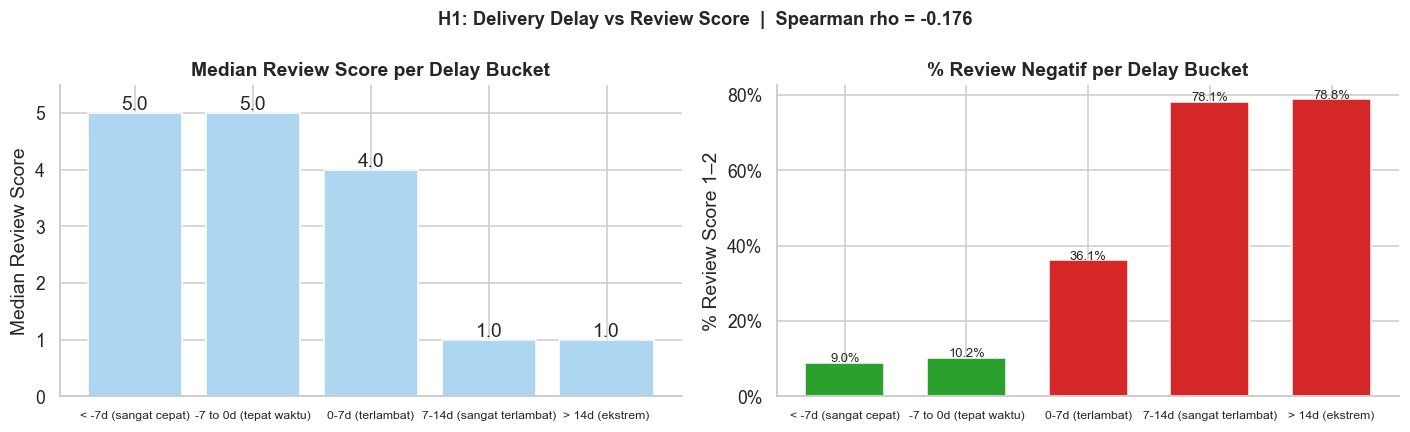


FINDING H1: rho = -0.1759 — delivery delay berkorelasi negatif dengan review score.
Order yang terlambat >14 hari memiliki 78.8% review negatif.


In [37]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── Median score per bucket ──────────────────────────────────────────
bars = axes[0].bar(range(len(h1_bucket)), h1_bucket["median"], color="#AED6F1",
    edgecolor="white")

for bar, v in zip(bars, h1_bucket["median"]):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.05, f"{v:.1f}", ha="center")

axes[0].set_ylim(0, 5.5)
axes[0].set_xticks(range(len(h1_bucket)))
axes[0].set_xticklabels(
    [bucket_label.get(b, b) for b in h1_bucket["delay_bucket"]], fontsize=8)
axes[0].set_ylabel("Median Review Score")
axes[0].set_title("Median Review Score per Delay Bucket", fontweight="bold")

# ── % negatif per bucket ─────────────────────────────────────────
colors = [C_POS, C_POS, C_NEG, C_NEG, C_NEG]
bars = axes[1].bar(range(len(h1_bucket)), h1_bucket["pct_negative"],
                   color=colors, edgecolor="white", width=0.65)
axes[1].set_xticks(range(len(h1_bucket)))
axes[1].set_xticklabels(
    [bucket_label.get(b, b) for b in h1_bucket["delay_bucket"]], fontsize=8)
axes[1].set_ylabel("% Review Score 1–2")
axes[1].set_title("% Review Negatif per Delay Bucket", fontweight="bold")
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())
for bar, v in zip(bars, h1_bucket["pct_negative"]):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3, f"{v:.1f}%", ha="center", fontsize=8.5)

plt.suptitle(f"H1: Delivery Delay vs Review Score  |  Spearman rho = {rho:.3f}",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\nFINDING H1: rho = {rho:.4f} — delivery delay berkorelasi negatif dengan review score.")
print(f"Order yang terlambat >14 hari memiliki {h1_bucket[h1_bucket['delay_bucket']=='very_late']['pct_negative'].values[0]:.1f}% review negatif.")


---
## H2 — Apakah Ada Seller dengan Rating Buruk Secara Konsisten?

**Hipotesis:** Sebagian seller secara konsisten mendapat rating rendah, dan volumenya cukup besar untuk berdampak signifikan.  
**Metode:** Agregasi avg score + order count per seller → scatter plot → flag outlier.  
**Prioritas:** Seller dengan volume tinggi DAN rata-rata skor rendah. Volume rendah diabaikan.


In [38]:
# ── Seller performance aggregation ──────────────────────────────
seller_perf = (df.groupby("seller_id")
    .agg(
        avg_score    = ("review_score",   "mean"),
        median_score = ("review_score",   "median"),
        n_orders     = ("order_id",       "count"),
        pct_negative = ("review_score",   lambda x: (x <= 2).mean() * 100),
        seller_state = ("seller_state",   "first"),
        seller_city  = ("seller_city",    "first"),
    )
    .reset_index())

# Threshold: high-volume = top 25% order count
vol_threshold   = seller_perf["n_orders"].quantile(0.75)
score_threshold = seller_perf["avg_score"].mean() - seller_perf["avg_score"].std()

# Flag: high volume AND below-average score
seller_perf["flag"] = (
    (seller_perf["n_orders"] >= vol_threshold) &
    (seller_perf["avg_score"] < score_threshold)
)

flagged = seller_perf[seller_perf["flag"]].sort_values("avg_score")

print(f"[H2] Seller Performance")
print(f"  Total sellers           : {len(seller_perf):,}")
print(f"  Volume threshold (p75)  : {vol_threshold:.0f} orders")
print(f"  Score threshold         : {score_threshold:.3f}")
print(f"  Flagged (high-vol+bad)  : {len(flagged):,} sellers")
print()
print("Top 10 worst high-volume sellers:")
display(flagged.head(10)[["seller_id","avg_score","n_orders",
                           "pct_negative","seller_state","seller_city"]]
        .style.format({"avg_score":"{:.3f}", "pct_negative":"{:.1f}%"})
        .bar(subset=["pct_negative"], color=C_NEG, vmax=60))


[H2] Seller Performance
  Total sellers           : 2,956
  Volume threshold (p75)  : 22 orders
  Score threshold         : 3.432
  Flagged (high-vol+bad)  : 19 sellers

Top 10 worst high-volume sellers:


,seller_id,avg_score,n_orders,pct_negative,seller_state,seller_city
321,1ca7077d890b907f89be8c954a02686a,2.393,107,59.8%,SP,santana de parnaiba
535,2eb70248d66e0e3ef83659f71b244378,2.780,182,47.8%,SP,campinas
1917,a49928bcdf77c55c6d6e05e09a9b4ca5,3.064,94,39.4%,SP,sao paulo
1768,972d0f9cf61b499a4812cf0bfa3ad3c4,3.108,74,40.5%,SC,brusque
473,2a1348e9addc1af5aaa619b1a3679d6b,3.170,47,36.2%,MG,belo horizonte
993,54965bbe3e4f07ae045b90b0b8541f52,3.176,68,39.7%,PR,foz do iguacu
1132,602044f2c16190c2c6e45eb35c2e21cb,3.244,45,35.6%,SP,ibitinga
2159,bbad7e518d7af88a0897397ffdca1979,3.246,65,38.5%,SP,sao paulo
927,5058e8c1e82653974541e83690655b4a,3.283,60,30.0%,SP,itaquaquecetuba
1557,8444e55c1f13cd5c179851e5ca5ebd00,3.352,91,33.0%,MG,congonhal


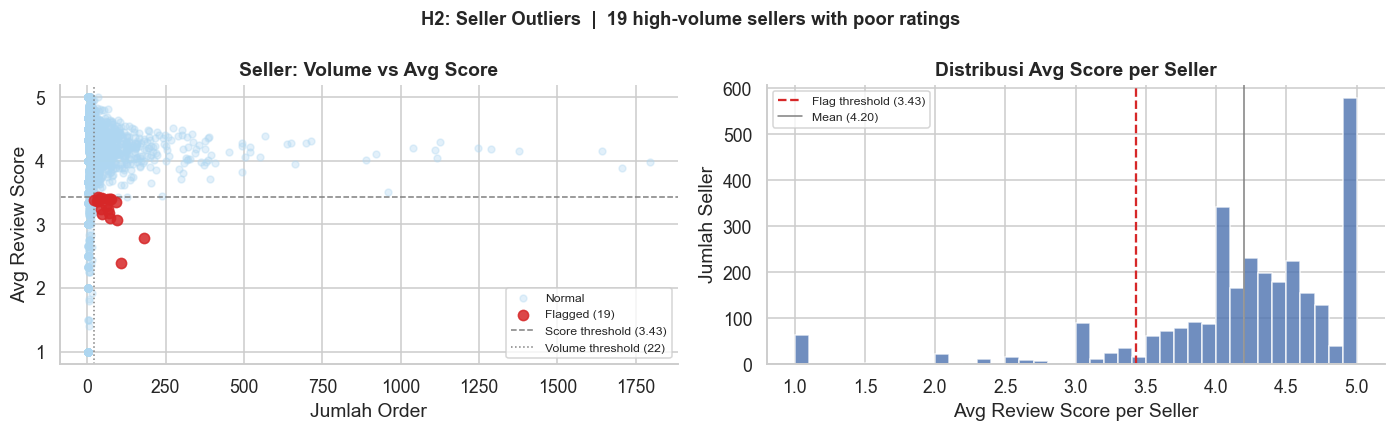


FINDING H2: 19 sellers teridentifikasi sebagai outlier negatif
(volume tinggi, avg score < 3.43)
Saved: mart_seller_perf.csv


In [39]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── Scatter: volume vs avg score ─────────────────────────────────
normal  = seller_perf[~seller_perf["flag"]]
outlier = seller_perf[seller_perf["flag"]]

axes[0].scatter(normal["n_orders"],  normal["avg_score"],
                alpha=0.35, s=20, color="#AED6F1", label="Normal")
axes[0].scatter(outlier["n_orders"], outlier["avg_score"],
                alpha=0.85, s=45, color=C_NEG, label=f"Flagged ({len(outlier)})", zorder=5)
axes[0].axhline(score_threshold, color="gray", linestyle="--",
                linewidth=1, label=f"Score threshold ({score_threshold:.2f})")
axes[0].axvline(vol_threshold, color="gray", linestyle=":",
                linewidth=1, label=f"Volume threshold ({vol_threshold:.0f})")
axes[0].set_xlabel("Jumlah Order")
axes[0].set_ylabel("Avg Review Score")
axes[0].set_title("Seller: Volume vs Avg Score", fontweight="bold")
axes[0].legend(fontsize=8)

# ── Distribution avg score ───────────────────────────────────────
axes[1].hist(seller_perf["avg_score"], bins=40, color=C_MID,
             alpha=0.8, edgecolor="white")
axes[1].axvline(score_threshold, color=C_NEG, linestyle="--",
                linewidth=1.5, label=f"Flag threshold ({score_threshold:.2f})")
axes[1].axvline(seller_perf["avg_score"].mean(), color="gray",
                linestyle="-", linewidth=1, label=f"Mean ({seller_perf['avg_score'].mean():.2f})")
axes[1].set_xlabel("Avg Review Score per Seller")
axes[1].set_ylabel("Jumlah Seller")
axes[1].set_title("Distribusi Avg Score per Seller", fontweight="bold")
axes[1].legend(fontsize=8)

plt.suptitle(f"H2: Seller Outliers  |  {len(flagged)} high-volume sellers with poor ratings",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

# Export for ClickHouse mart
seller_perf.to_csv(PROCESSED / "mart_seller_perf.csv", index=False)
print(f"\nFINDING H2: {len(flagged)} sellers teridentifikasi sebagai outlier negatif")
print(f"(volume tinggi, avg score < {score_threshold:.2f})")
print(f"Saved: mart_seller_perf.csv")


---
## H3 — Kategori Produk Mana yang Mendapat Rating Terendah?

**Hipotesis:** Beberapa kategori produk secara konsisten mendapat review lebih rendah.  
**Metode:** Median review score per kategori (lebih robust dari mean untuk distribusi skewed).  
**Filter:** Minimum 30 orders per kategori agar median reliable.


In [40]:
# ── Median score per category ────────────────────────────────────
MIN_ORDERS = 30

cat_perf = (df.dropna(subset=["product_category_name_english"])
    .groupby("product_category_name_english")
    .agg(
        median_score = ("review_score",  "median"),
        avg_score    = ("review_score",  "mean"),
        n_orders     = ("order_id",      "count"),
        pct_negative = ("review_score",  lambda x: (x <= 2).mean() * 100),
    )
    .reset_index()
    .query(f"n_orders >= {MIN_ORDERS}")
    .sort_values("median_score", ascending=True)
    .reset_index(drop=True))

print(f"[H3] Product Category Performance")
print(f"  Total categories (≥{MIN_ORDERS} orders): {len(cat_perf)}")
print()
print("Bottom 10 categories (lowest median score):")
display(cat_perf.head(10)[["product_category_name_english",
                            "median_score","avg_score","n_orders","pct_negative"]]
        .style.format({"median_score":"{:.2f}","avg_score":"{:.2f}",
                       "n_orders":"{:,}","pct_negative":"{:.1f}%"})
        .bar(subset=["pct_negative"], color=C_NEG, vmax=50))


[H3] Product Category Performance
  Total categories (≥30 orders): 62

Bottom 10 categories (lowest median score):


,product_category_name_english,median_score,avg_score,n_orders,pct_negative
0,office_furniture,4.00,3.65,"1,236",21.8%
1,fashio_female_clothing,4.50,3.92,36,16.7%
2,agro_industry_and_commerce,5.00,4.11,177,12.4%
3,furniture_decor,5.00,4.07,"6,167",15.0%
4,furniture_living_room,5.00,4.09,404,13.4%
5,furniture_mattress_and_upholstery,5.00,3.89,37,18.9%
6,garden_tools,5.00,4.19,"3,395",11.9%
7,health_beauty,5.00,4.23,"8,562",11.3%
8,home_appliances,5.00,4.21,744,11.0%
9,home_appliances_2,5.00,4.16,225,12.4%


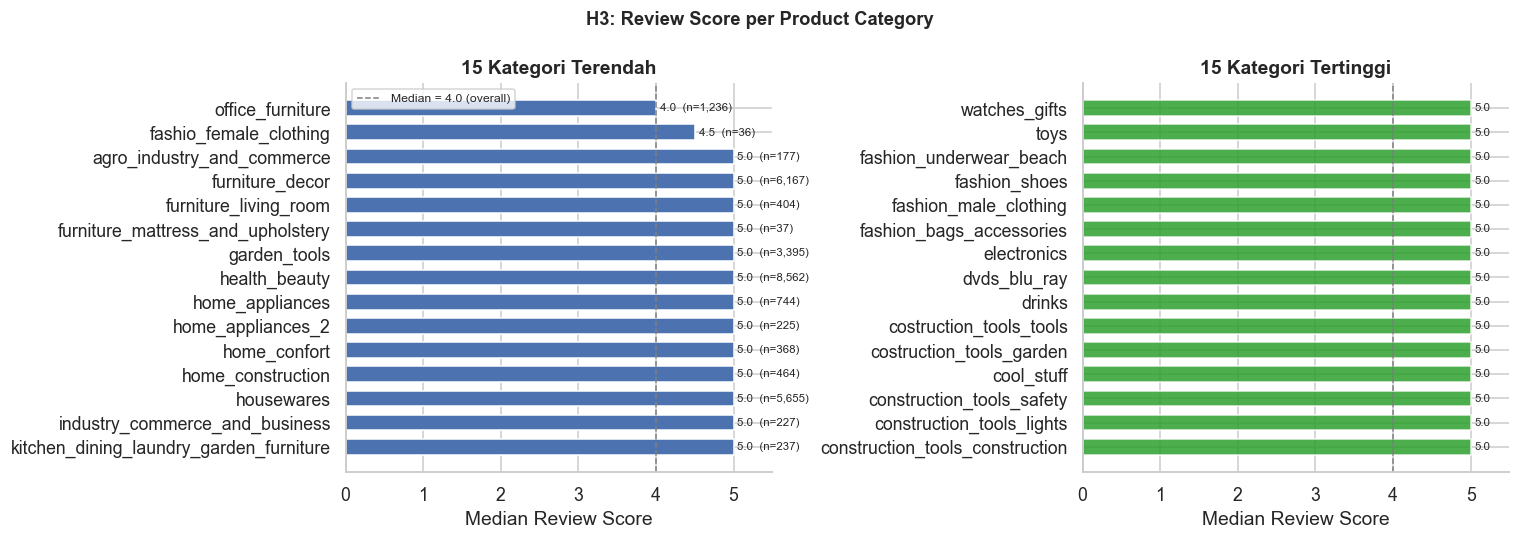


FINDING H3: Kategori terendah = 'office_furniture'
  Median score: 4.00, % negatif: 21.8%  (n=1,236)
Saved: mart_category_score.csv


In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Bottom 15 categories ─────────────────────────────────────────
bottom15 = cat_perf.head(15)
colors_bar = [C_NEG if s < 4.0 else C_MID for s in bottom15["median_score"]]
axes[0].barh(bottom15["product_category_name_english"][::-1],
             bottom15["median_score"][::-1],
             color=colors_bar[::-1], edgecolor="white", height=0.65)
axes[0].axvline(4.0, color="gray", linestyle="--", linewidth=1,
                label="Median = 4.0 (overall)")
axes[0].set_xlabel("Median Review Score")
axes[0].set_title("15 Kategori Terendah", fontweight="bold")
axes[0].set_xlim(0, 5.5)
axes[0].legend(fontsize=8)
for i, (_, row) in enumerate(bottom15[::-1].iterrows()):
    axes[0].text(row["median_score"] + 0.05, i,
                 f"{row['median_score']:.1f}  (n={row['n_orders']:,})",
                 va="center", fontsize=7.5)

# ── Top 15 categories ────────────────────────────────────────────
top15 = cat_perf.tail(15)
axes[1].barh(top15["product_category_name_english"],
             top15["median_score"],
             color=C_POS, edgecolor="white", height=0.65, alpha=0.85)
axes[1].axvline(4.0, color="gray", linestyle="--", linewidth=1)
axes[1].set_xlabel("Median Review Score")
axes[1].set_title("15 Kategori Tertinggi", fontweight="bold")
axes[1].set_xlim(0, 5.5)
for i, (_, row) in enumerate(top15.iterrows()):
    axes[1].text(row["median_score"] + 0.05, i,
                 f"{row['median_score']:.1f}", va="center", fontsize=7.5)

plt.suptitle("H3: Review Score per Product Category", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

# Export
cat_perf.to_csv(PROCESSED / "mart_category_score.csv", index=False)
worst_cat = cat_perf.iloc[0]
print(f"\nFINDING H3: Kategori terendah = '{worst_cat['product_category_name_english']}'")
print(f"  Median score: {worst_cat['median_score']:.2f}, "
      f"% negatif: {worst_cat['pct_negative']:.1f}%  (n={worst_cat['n_orders']:,})")
print(f"Saved: mart_category_score.csv")


---
## H4 — Apakah Ada Pola Geografis dalam Kepuasan Pelanggan?

**Hipotesis:** State tertentu memiliki kepuasan pelanggan lebih rendah,  
kemungkinan berkorelasi dengan performa pengiriman di wilayah tersebut.  
**Metode:** Median review score + median delivery delay per `customer_state`.  
**Insight kunci:** Apakah state dengan score rendah juga state dengan delay tinggi?


In [42]:
# ── Aggregation per state ────────────────────────────────────────
geo_perf = (df.dropna(subset=["customer_state"])
    .groupby("customer_state")
    .agg(
        median_score    = ("review_score",          "median"),
        avg_score       = ("review_score",          "mean"),
        n_orders        = ("order_id",              "count"),
        pct_negative    = ("review_score",          lambda x: (x <= 2).mean() * 100),
        median_delay    = ("delivery_delay_days",   "median"),
        pct_late        = ("is_late",               "mean"),
    )
    .reset_index()
    .sort_values("median_score", ascending=True))
geo_perf = geo_perf.reset_index(drop=True)
geo_perf.index += 1

geo_perf["pct_late"] = geo_perf["pct_late"] * 100

print(f"[H4] Geographic Performance")
print(f"  Total states   : {len(geo_perf)}")
print()
print("States sorted by median score (worst to best):")
display(geo_perf[["customer_state","median_score","avg_score",
                   "n_orders","pct_negative","median_delay","pct_late"]]
        .style.format({"median_score":"{:.2f}","avg_score":"{:.2f}",
                       "n_orders":"{:,}","pct_negative":"{:.1f}%",
                       "median_delay":"{:.1f}","pct_late":"{:.1f}%"})
        .bar(subset=["pct_negative"], color=C_NEG, vmax=30))


[H4] Geographic Performance
  Total states   : 27

States sorted by median score (worst to best):


,customer_state,median_score,avg_score,n_orders,pct_negative,median_delay,pct_late
1,AL,4.00,3.85,394,21.3%,-9.6,23.4%
2,RR,4.00,3.90,41,14.6%,-19.1,12.2%
3,MA,4.00,3.83,712,19.9%,-10.0,19.2%
4,AC,5.00,4.09,80,15.0%,-21.2,3.8%
5,SE,5.00,3.91,334,18.9%,-12.2,15.0%
6,SC,5.00,4.13,"3,519",13.0%,-12.1,9.6%
7,RS,5.00,4.18,"5,327",11.9%,-14.0,7.1%
8,RO,5.00,4.17,242,12.0%,-20.2,2.9%
9,RN,5.00,4.15,471,13.0%,-14.4,10.6%
10,RJ,5.00,3.97,"12,211",18.3%,-12.3,13.3%


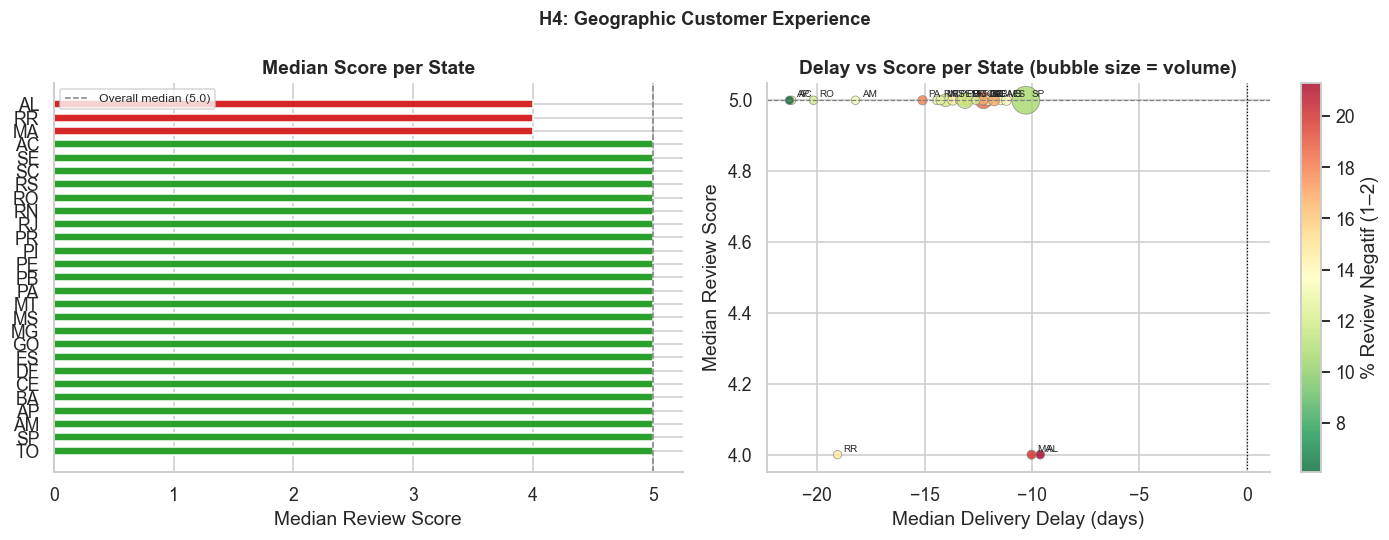


FINDING H4: State terendah = 'AL'
  Median score: 4.00, median delay: -9.6d, % negatif: 21.3%
Saved: mart_geo_score.csv


In [43]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Bar: median score per state ──────────────────────────────────
overall_median = df["review_score"].median()
colors_geo = [C_NEG if s < overall_median else C_POS
              for s in geo_perf["median_score"]]

axes[0].barh(geo_perf["customer_state"][::-1],
             geo_perf["median_score"][::-1],
             color=colors_geo[::-1], edgecolor="white", height=0.6)
axes[0].axvline(overall_median, color="gray", linestyle="--",
                linewidth=1, label=f"Overall median ({overall_median:.1f})")
axes[0].set_xlabel("Median Review Score")
axes[0].set_title("Median Score per State", fontweight="bold")
axes[0].legend(fontsize=8)

# ── Scatter: delay vs score per state ────────────────────────────
sc = axes[1].scatter(
    geo_perf["median_delay"],
    geo_perf["median_score"],
    s=geo_perf["n_orders"] / geo_perf["n_orders"].max() * 300 + 30,
    c=geo_perf["pct_negative"], cmap="RdYlGn_r", alpha=0.8,
    edgecolors="gray", linewidths=0.5)

plt.colorbar(sc, ax=axes[1], label="% Review Negatif (1–2)")

for _, row in geo_perf.iterrows():
    axes[1].annotate(row["customer_state"],
                     (row["median_delay"], row["median_score"]),
                     textcoords="offset points", xytext=(4, 2), fontsize=6.5)

axes[1].set_xlabel("Median Delivery Delay (days)")
axes[1].set_ylabel("Median Review Score")
axes[1].set_title("Delay vs Score per State (bubble size = volume)", fontweight="bold")
axes[1].axhline(overall_median, color="gray", linestyle="--", linewidth=0.8)
axes[1].axvline(0, color="black", linestyle=":", linewidth=0.8)

plt.suptitle("H4: Geographic Customer Experience", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

# Export
geo_perf.to_csv(PROCESSED / "mart_geo_score.csv", index=False)
worst_state = geo_perf.iloc[0]
print(f"\nFINDING H4: State terendah = '{worst_state['customer_state']}'")
print(f"  Median score: {worst_state['median_score']:.2f}, "
      f"median delay: {worst_state['median_delay']:.1f}d, "
      f"% negatif: {worst_state['pct_negative']:.1f}%")
print(f"Saved: mart_geo_score.csv")


---
## H5 — Keluhan Apa yang Paling Sering Muncul di Review Negatif?

**Input:** `negative_reviews_text.csv` (score 1–2 dengan komentar teks)  
**Metode:** TF-IDF → top terms + bigrams → kelompokkan secara manual ke tema.  
**Bahasa:** Portugis (dataset Olist) — stopwords dari NLTK.  

> Kalau NLTK stopwords belum di-download, cell pertama akan menanganinya otomatis.


In [44]:
import nltk
from sklearn.feature_extraction.text import TfidfVectorizer
import re

# Download stopwords kalau belum ada
try:
    from nltk.corpus import stopwords
    STOPWORDS_PT = set(stopwords.words("portuguese"))
except LookupError:
    nltk.download("stopwords", quiet=True)
    from nltk.corpus import stopwords
    STOPWORDS_PT = set(stopwords.words("portuguese"))

# Tambah custom stopwords yang tidak relevan untuk analisis keluhan
CUSTOM_STOP = {
    "produto", "produtos", "compra", "loja", "recebi", "chegou",
    "prazo", "nao", "nao", "muito", "mais", "mas", "bem", "foi",
    "era", "ja", "ate", "so", "ser", "ter", "com", "por", "para",
    "isso", "esta", "esse", "quando", "ainda", "pois", "porem",
    "tambem", "boa", "bom", "otimo", "otima", "ótimo", "ótima"
}
STOPWORDS_PT.update(CUSTOM_STOP)

neg_text = pd.read_csv(PROCESSED / "negative_reviews_text.csv")
print(f"Corpus: {len(neg_text):,} negative reviews (score 1-2)")
print(f"Score distribution:")
print(neg_text["review_score"].value_counts().sort_index().to_string())


Corpus: 10,839 negative reviews (score 1-2)
Score distribution:
review_score
1    8706
2    2133


In [45]:
def clean_text(text: str) -> str:
    """Basic normalization: lowercase, remove punctuation, keep alpha only."""
    text = str(text).lower()
    text = re.sub(r"[^a-záéíóúâêîôûãõàèìòùç\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

corpus = neg_text["review_comment_message"].fillna("").apply(clean_text)
corpus = corpus[corpus.str.len() > 5]  # remove near-empty strings

print(f"Corpus after cleaning: {len(corpus):,} documents")
print(f"Avg text length      : {corpus.str.len().mean():.0f} chars")


Corpus after cleaning: 10,771 documents
Avg text length      : 96 chars


In [46]:
# ── TF-IDF: Unigrams ────────────────────────────────────────────
tfidf_uni = TfidfVectorizer(
    stop_words=list(STOPWORDS_PT),
    ngram_range=(1, 1),
    max_features=100,
    min_df=20,          # muncul minimal di 20 dokumen
    max_df=0.85,        # ignore terms yang terlalu umum
)
X_uni = tfidf_uni.fit_transform(corpus)
uni_scores = pd.Series(
    X_uni.toarray().mean(axis=0),
    index=tfidf_uni.get_feature_names_out()
).sort_values(ascending=False)

# ── TF-IDF: Bigrams ─────────────────────────────────────────────
tfidf_bi = TfidfVectorizer(
    stop_words=list(STOPWORDS_PT),
    ngram_range=(2, 2),
    max_features=60,
    min_df=15,
    max_df=0.85,
)
X_bi = tfidf_bi.fit_transform(corpus)
bi_scores = pd.Series(
    X_bi.toarray().mean(axis=0),
    index=tfidf_bi.get_feature_names_out()
).sort_values(ascending=False)

print("Top 20 unigrams:")
print(uni_scores.head(20).to_string())
print()
print("Top 20 bigrams:")
print(bi_scores.head(20).to_string())


Top 20 unigrams:
comprei       0.064334
veio          0.059990
entregue      0.056987
entrega       0.056563
pedido        0.032449
agora         0.029127
dia           0.028210
qualidade     0.024236
apenas        0.023474
nada          0.022342
aguardando    0.021626
quero         0.021523
site          0.021399
lannister     0.021173
dois          0.020904
outro         0.019428
dias          0.019265
contato       0.019206
momento       0.018789
porém         0.018492

Top 20 bigrams:
nota fiscal             0.020009
comprei dois            0.013714
veio defeito            0.010606
dinheiro volta          0.010215
gostaria saber          0.010092
péssima qualidade       0.009152
agora nada              0.007757
lojas lannister         0.007753
fiz pedido              0.007338
veio errado             0.007206
veio faltando           0.007177
comprei duas            0.006996
entrar contato          0.006692
falta respeito          0.006041
demora entrega          0.005953
quero dinhe

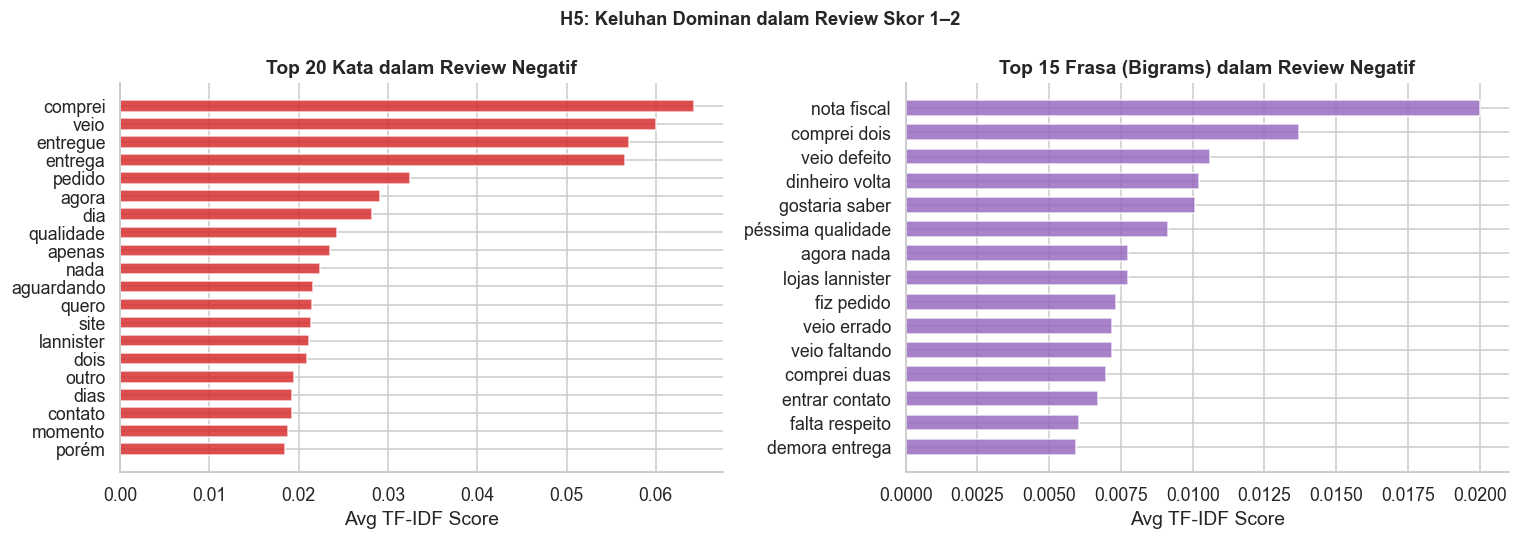

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Top 20 unigrams ──────────────────────────────────────────────
top_uni = uni_scores.head(20)
axes[0].barh(top_uni.index[::-1], top_uni.values[::-1],
             color=C_NEG, alpha=0.82, edgecolor="white", height=0.65)
axes[0].set_xlabel("Avg TF-IDF Score")
axes[0].set_title("Top 20 Kata dalam Review Negatif", fontweight="bold")

# ── Top 15 bigrams ───────────────────────────────────────────────
top_bi = bi_scores.head(15)
axes[1].barh(top_bi.index[::-1], top_bi.values[::-1],
             color="#9467bd", alpha=0.82, edgecolor="white", height=0.65)
axes[1].set_xlabel("Avg TF-IDF Score")
axes[1].set_title("Top 15 Frasa (Bigrams) dalam Review Negatif", fontweight="bold")

plt.suptitle("H5: Keluhan Dominan dalam Review Skor 1–2", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


In [48]:
# ── Manual theme grouping ────────────────────────────────────────
# Setelah melihat output di atas, kelompokkan term ke tema bisnis
# EDIT dictionary ini berdasarkan top terms aktual yang muncul

CUSTOM_STOP.update({
    "lannister", "lojas",  # noise: nama seller spesifik
})

THEME_KEYWORDS = {
    "Pengiriman Tidak Sampai/Hilang": [
        "entregue", "nao chegou", "nao recebi", "aguardando",
        "cadê", "cade", "sumiram", "sumiu", "paradox"
    ],
    "Keterlambatan Pengiriman": [
        "demora", "demorou", "demora entrega", "atrasado", "atraso",
        "dias", "dia", "prazo", "tarde"
    ],
    "Produk Rusak": [
        "defeito", "veio defeito", "quebrado", "danificado",
        "estragado", "avariado", "problema"
    ],
    "Produk Tidak Sesuai Deskripsi": [
        "totalmente diferente", "veio errado", "veio faltando",
        "qualidade", "péssima qualidade", "pessima qualidade",
        "diferente", "errado", "foto"
    ],
    "Masalah Refund": [
        "dinheiro volta", "quero dinheiro", "reembolso",
        "devolucao", "devolver", "cancelar", "troca"
    ],
    "Masalah Nota Fiscal/Administratif": [
        "nota fiscal", "documento", "imposto", "nf"
    ],
    "Kesulitan Menghubungi Seller/Support": [
        "entrar contato", "entrei contato", "contato",
        "resposta", "atendimento", "suporte", "ignorou", "ninguem"
    ],
}

# Count dokumen yang mengandung setiap tema
theme_counts = {}
for theme, keywords in THEME_KEYWORDS.items():
    pattern = "|".join(keywords)
    count = corpus.str.contains(pattern, case=False, regex=True).sum()
    theme_counts[theme] = count

theme_df = (pd.DataFrame.from_dict(theme_counts, orient="index", columns=["n_reviews"])
              .sort_values("n_reviews", ascending=False))
theme_df["pct_of_corpus"] = theme_df["n_reviews"] / len(corpus) * 100

display(theme_df.style
    .format({"n_reviews":"{:,}", "pct_of_corpus":"{:.1f}%"})
    .bar(subset=["pct_of_corpus"], color=C_NEG, vmax=60)
    .set_caption("H5: Tema keluhan dalam review negatif"))

# Export
tfidf_results = pd.DataFrame({
    "term" : uni_scores.head(50).index,
    "tfidf_score": uni_scores.head(50).values,
    "type": "unigram"
})
tfidf_results.to_csv(PROCESSED / "mart_tfidf_terms.csv", index=False)
print(f"\nFINDING H5: Tema paling dominan = '{theme_df.index[0]}'")
print(f"  Muncul di {theme_df.iloc[0]['n_reviews']:,} dari {len(corpus):,} review negatif "
      f"({theme_df.iloc[0]['pct_of_corpus']:.1f}%)")
print(f"Saved: mart_tfidf_terms.csv")

,n_reviews,pct_of_corpus
Keterlambatan Pengiriman,"2,243",20.8%
Pengiriman Tidak Sampai/Hilang,"2,068",19.2%
Produk Tidak Sesuai Deskripsi,"1,217",11.3%
Masalah Nota Fiscal/Administratif,"1,180",11.0%
Kesulitan Menghubungi Seller/Support,906,8.4%
Produk Rusak,812,7.5%
Masalah Refund,787,7.3%



FINDING H5: Tema paling dominan = 'Keterlambatan Pengiriman'
  Muncul di 2,243.0 dari 10,771 review negatif (20.8%)
Saved: mart_tfidf_terms.csv


---
## H6 — Faktor Mana yang Paling Berpengaruh terhadap Review Score Rendah?

**Tujuan:** Rank kontribusi relatif delivery delay, performa seller, kategori produk,  
dan geografi terhadap review score — dikontrol secara simultan.  
**Metode:** Ordinal Logistic Regression (review_score = variabel ordinal 1–5).  
**Output:** Pseudo-R² per faktor + koefisien yang bisa dibandingkan langsung.

> Kenapa bukan Linear Regression?  
> review_score adalah variabel ordinal — jarak antara skor 1→2 tidak sama dengan 2→3.  
> Ordinal Logistic Regression menghormati struktur ordinal ini.


In [49]:
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
import scipy.stats as st

# ── Build feature matrix ─────────────────────────────────────────
h6 = df.dropna(subset=["review_score", "delivery_delay_days",
                        "seller_id", "product_category_name_english",
                        "customer_state"]).copy()

# Feature 1: delivery delay (continuous)
h6["f_delay"] = h6["delivery_delay_days"]

# Feature 2: seller avg score (continuous proxy untuk seller quality)
seller_avg = df.groupby("seller_id")["review_score"].mean().rename("f_seller_avg")
h6 = h6.merge(seller_avg, on="seller_id", how="left")

# Feature 3: category encoded (frequency encoding — lebih stable dari label encoding)
cat_freq = df["product_category_name_english"].value_counts(normalize=True)
h6["f_cat_freq"] = h6["product_category_name_english"].map(cat_freq)

# Feature 4: state encoded (frequency encoding)
state_freq = df["customer_state"].value_counts(normalize=True)
h6["f_state_freq"] = h6["customer_state"].map(state_freq)

# Binary target: negatif (1-2) = 1, positif/netral (3-5) = 0
h6["target_binary"] = (h6["review_score"] <= 2).astype(int)

FEATURES = ["f_delay", "f_seller_avg", "f_cat_freq", "f_state_freq"]
h6_clean = h6[FEATURES + ["target_binary"]].dropna()

X = h6_clean[FEATURES].values
y = h6_clean["target_binary"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"[H6] Feature matrix: {X_scaled.shape[0]:,} rows x {len(FEATURES)} features")
print(f"Target distribution: {y.mean()*100:.1f}% negatif, {(1-y.mean())*100:.1f}% positif/netral")


[H6] Feature matrix: 94,474 rows x 4 features
Target distribution: 12.8% negatif, 87.2% positif/netral


In [50]:
# ── Logistic Regression ──────────────────────────────────────────
from sklearn.model_selection import cross_val_score

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_scaled, y)

feature_names = ["Delivery Delay", "Seller Avg Score", "Category (freq)", "State (freq)"]
coef_df = pd.DataFrame({
    "feature"        : feature_names,
    "coefficient"    : lr.coef_[0],
    "abs_coefficient": np.abs(lr.coef_[0]),
}).sort_values("abs_coefficient", ascending=False)

# Cross-val score sebagai proxy goodness of fit
cv_scores = cross_val_score(lr, X_scaled, y, cv=5, scoring="roc_auc")

print(f"[H6] Logistic Regression Results")
print(f"  CV AUC (5-fold) : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print()
display(coef_df.style
    .format({"coefficient":"{:.4f}", "abs_coefficient":"{:.4f}"})
    .bar(subset=["abs_coefficient"], color=C_MID)
    .set_caption("H6: Feature coefficients (standardized) — higher |coef| = stronger influence"))


[H6] Logistic Regression Results
  CV AUC (5-fold) : 0.7279 ± 0.0068



,feature,coefficient,abs_coefficient
0,Delivery Delay,0.7245,0.7245
1,Seller Avg Score,-0.5398,0.5398
3,State (freq),-0.1817,0.1817
2,Category (freq),0.0283,0.0283


In [51]:
# ── Individual Spearman per feature (sebagai cross-check) ────────
print("[H6] Spearman Correlation per feature vs review_score (cross-check):")
for feat, name in zip(FEATURES, feature_names):
    vals = h6_clean[feat]
    rho_f, p_f = stats.spearmanr(vals, h6_clean["target_binary"])
    sig_str = "***" if p_f < 0.001 else "**" if p_f < 0.01 else "*" if p_f < 0.05 else "n.s."
    print(f"  {name:<25} rho={rho_f:+.4f}  {sig_str}")

print()
print("Cross-check logic: koefisien positif di LR artinya faktor itu")
print("meningkatkan probabilitas review NEGATIF (target=1).")
print("Spearman negatif dengan review_score = konsisten.")


[H6] Spearman Correlation per feature vs review_score (cross-check):
  Delivery Delay            rho=+0.1810  ***
  Seller Avg Score          rho=-0.1826  ***
  Category (freq)           rho=+0.0179  ***
  State (freq)              rho=-0.0423  ***

Cross-check logic: koefisien positif di LR artinya faktor itu
meningkatkan probabilitas review NEGATIF (target=1).
Spearman negatif dengan review_score = konsisten.


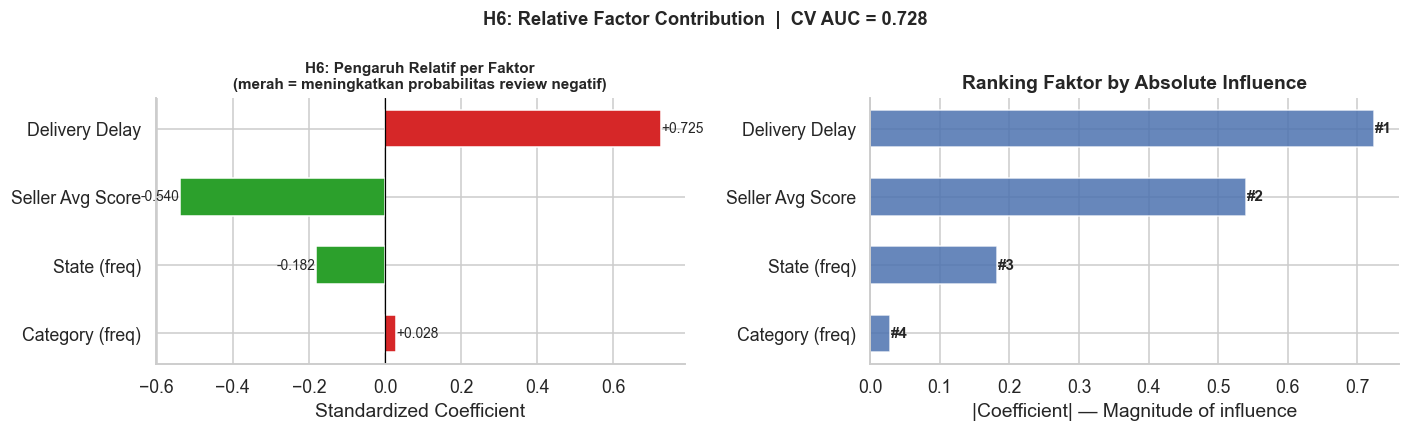


FINDING H6: Faktor paling berpengaruh = 'Delivery Delay'
  |Coefficient| = 0.7245
  CV AUC = 0.7279
Saved: mart_factor_ranking.csv


In [52]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── Coefficient bar chart ─────────────────────────────────────────
bar_colors = [C_NEG if c > 0 else C_POS for c in coef_df["coefficient"]]
bars = axes[0].barh(coef_df["feature"][::-1],
                    coef_df["coefficient"][::-1],
                    color=bar_colors[::-1], edgecolor="white", height=0.55)
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_xlabel("Standardized Coefficient")
axes[0].set_title("H6: Pengaruh Relatif per Faktor\n(merah = meningkatkan probabilitas review negatif)",
                  fontweight="bold", fontsize=10)
for bar, val in zip(bars, coef_df["coefficient"][::-1]):
    axes[0].text(val + (0.002 if val >= 0 else -0.002),
                 bar.get_y() + bar.get_height()/2,
                 f"{val:+.3f}", va="center",
                 ha="left" if val >= 0 else "right", fontsize=9)

# ── Ranking visual ────────────────────────────────────────────────
rank_df = coef_df.reset_index(drop=True)
axes[1].barh(rank_df["feature"][::-1],
             rank_df["abs_coefficient"][::-1],
             color=C_MID, edgecolor="white", height=0.55, alpha=0.85)
axes[1].set_xlabel("|Coefficient| — Magnitude of influence")
axes[1].set_title("Ranking Faktor by Absolute Influence", fontweight="bold")
for i, (_, row) in enumerate(rank_df[::-1].iterrows()):
    axes[1].text(row["abs_coefficient"] + 0.001, i,
                 f"#{len(rank_df)-i}", va="center", fontsize=10, fontweight="bold")

plt.suptitle(f"H6: Relative Factor Contribution  |  CV AUC = {cv_scores.mean():.3f}",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

# Export
h6_export = coef_df.copy()
h6_export["cv_auc"] = cv_scores.mean()
h6_export.to_csv(PROCESSED / "mart_factor_ranking.csv", index=False)

top_factor = coef_df.iloc[0]
print(f"\nFINDING H6: Faktor paling berpengaruh = '{top_factor['feature']}'")
print(f"  |Coefficient| = {top_factor['abs_coefficient']:.4f}")
print(f"  CV AUC = {cv_scores.mean():.4f}")
print(f"Saved: mart_factor_ranking.csv")


---
## Findings Summary

Ringkasan semua temuan.

In [53]:
print("=" * 60)
print("  FINDINGS SUMMARY — DustiniaDelixia CX Analysis")
print("=" * 60)

summary = [
    ("H1", "Delivery Delay vs Score",
     f"Spearman rho = {rho:.4f}  |  {'Negatif signifikan' if rho < -0.1 else 'Lemah'}"),
    ("H2", "Seller Outliers",
     f"{len(flagged):,} seller high-volume dengan avg score < {score_threshold:.2f}"),
    ("H3", "Product Category",
     f"Kategori terendah: '{worst_cat['product_category_name_english']}'  "
     f"(median={worst_cat['median_score']:.1f}, {worst_cat['pct_negative']:.0f}% negatif)"),
    ("H4", "Geographic",
     f"State terendah: '{worst_state['customer_state']}'  "
     f"(median delay={worst_state['median_delay']:.1f}d)"),
    ("H5", "Keluhan Dominan",
     f"Tema terbesar: '{theme_df.index[0]}'  ({theme_df.iloc[0]['pct_of_corpus']:.0f}% corpus)"),
    ("H6", "Factor Ranking",
     f"#{1} = '{coef_df.iloc[0]['feature']}'  |  CV AUC = {cv_scores.mean():.3f}"),
]

for h, label, finding in summary:
    print(f"\n  [{h}] {label}")
    print(f"       {finding}")

print()
print("Exports saved to data/processed/:")
for fname in ["mart_seller_perf.csv", "mart_category_score.csv",
              "mart_geo_score.csv", "mart_tfidf_terms.csv", "mart_factor_ranking.csv"]:
    fpath = PROCESSED / fname
    exists = "✅" if fpath.exists() else "❌"
    print(f"  {exists} {fname}")


  FINDINGS SUMMARY — DustiniaDelixia CX Analysis

  [H1] Delivery Delay vs Score
       Spearman rho = -0.1759  |  Negatif signifikan

  [H2] Seller Outliers
       19 seller high-volume dengan avg score < 3.43

  [H3] Product Category
       Kategori terendah: 'office_furniture'  (median=4.0, 22% negatif)

  [H4] Geographic
       State terendah: 'AL'  (median delay=-9.6d)

  [H5] Keluhan Dominan
       Tema terbesar: 'Keterlambatan Pengiriman'  (21% corpus)

  [H6] Factor Ranking
       #1 = 'Delivery Delay'  |  CV AUC = 0.728

Exports saved to data/processed/:
  ✅ mart_seller_perf.csv
  ✅ mart_category_score.csv
  ✅ mart_geo_score.csv
  ✅ mart_tfidf_terms.csv
  ✅ mart_factor_ranking.csv
